# 02 - Split Strategy & Target EDA

### Notebook idea:
- wykonać chronologiczny podział `train/val/test`,
- zweryfikować brak leakage czasowego,
- przeprowadzić EDA zmiennej objaśnianej (`future_return`, `target`),
- zapisać zbiory do kolejnych etapów pipeline'u.


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stylin import InfoDisplayStyler


In [2]:
styler = InfoDisplayStyler()

In [3]:
DATA_PATH = '../../data/raw/ethusdt_1h.csv'
CLEAN_PATH = '../../data/clean/'
LABELED_PATH = '../../data/labeled/'

raw_data = pd.read_csv(DATA_PATH)
assert not raw_data.empty, "DataFrame is empty"

os.makedirs(CLEAN_PATH, exist_ok=True)
os.makedirs(LABELED_PATH, exist_ok=True)

LABELED_FILE = LABELED_PATH + 'eth_labeled.csv'
assert os.path.exists(LABELED_FILE), 'Brak data/labeled/eth_labeled.csv. Najpierw uruchom notebook 01.'

labeled_df = pd.read_csv(LABELED_FILE)
assert not labeled_df.empty, "Labeled DataFrame is empty"

styler.show_meta(labeled_df)
styler.style_me(labeled_df.head(5), title='Labeled data preview')


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,future_return,target
0,2021-01-01 00:00:00+00:00,736.420000,739.000000,729.330000,734.070000,27932.698840,20479903.476036,22671,15020.616630,11015918.972215,0.008037,2
1,2021-01-01 01:00:00+00:00,734.080000,749.000000,733.370000,748.280000,52336.187790,38899618.853014,41712,27395.902700,20362373.933503,-0.014567,0
2,2021-01-01 02:00:00+00:00,748.270000,749.000000,742.270000,744.060000,33019.501000,24606726.438367,19566,17721.266960,13207123.352084,-0.018802,0
3,2021-01-01 03:00:00+00:00,744.060000,747.230000,743.100000,744.820000,17604.808590,13119088.400414,12230,9499.749200,7079926.310875,-0.014957,0
4,2021-01-01 04:00:00+00:00,744.870000,747.090000,739.300000,742.290000,18794.154240,13980190.971469,13626,10133.742110,7539500.286872,-0.007383,1


### Split entry validation

In [4]:
required_cols = ['timestamp', 'target']
missing_required = [c for c in required_cols if c not in labeled_df.columns]
assert not missing_required, f"Brak wymaganych kolumn: {missing_required}"

labeled_df['timestamp'] = pd.to_datetime(labeled_df['timestamp'], utc=True, errors='coerce')

is_timestamp_valid = bool(labeled_df['timestamp'].notna().all())
is_target_valid = bool(labeled_df['target'].notna().all())

# Ensure chronological order for time-series split.
labeled_df = labeled_df.sort_values('timestamp').reset_index(drop=True)
is_monotonic = bool(labeled_df['timestamp'].is_monotonic_increasing)

timestamp_duplicates = int(labeled_df['timestamp'].duplicated().sum())
no_timestamp_duplicates = bool(timestamp_duplicates == 0)

labeled_df['target'] = labeled_df['target'].astype(int)

entry_validation = pd.DataFrame({
    'check': [
        'required columns present',
        'timestamp valid (no NaT)',
        'target valid (no NaN)',
        'timestamps monotonic increasing',
        'no duplicate timestamps',
    ],
    'pass': [
        True,
        is_timestamp_valid,
        is_target_valid,
        is_monotonic,
        no_timestamp_duplicates,
    ],
})

assert entry_validation['pass'].all(), 'Split entry validation failed. Sprawdz dane wejsciowe.'
styler.style_me(entry_validation, title='Split entry validation')


,check,pass
0,required columns present,True
1,timestamp valid (no NaT),True
2,target valid (no NaN),True
3,timestamps monotonic increasing,True
4,no duplicate timestamps,True


### Chronological split train/val/test

In [5]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert np.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0), 'Suma ratio musi byc rowna 1.0'

n = len(labeled_df)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_df = labeled_df.iloc[:train_end].copy()
val_df = labeled_df.iloc[train_end:val_end].copy()
test_df = labeled_df.iloc[val_end:].copy()

split_size_report = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'ratio_real': [len(train_df)/n, len(val_df)/n, len(test_df)/n],
    'start': [train_df['timestamp'].min(), val_df['timestamp'].min(), test_df['timestamp'].min()],
    'end': [train_df['timestamp'].max(), val_df['timestamp'].max(), test_df['timestamp'].max()],
})
styler.style_me(split_size_report, title='Split sizes and time ranges')


,split,rows,ratio_real,start,end
0,train,32376,0.699991,2021-01-01 00:00:00+00:00,2024-09-11 13:00:00+00:00
1,val,6937,0.149983,2024-09-11 14:00:00+00:00,2025-06-27 14:00:00+00:00
2,test,6939,0.150026,2025-06-27 15:00:00+00:00,2026-04-12 17:00:00+00:00


### Anti-leakage control (time)

In [6]:
split_checks = pd.DataFrame({
    'check': [
        'train_end < val_start',
        'val_end < test_start',
        'train timestamps unique',
        'val timestamps unique',
        'test timestamps unique',
    ],
    'pass': [
        bool(train_df['timestamp'].max() < val_df['timestamp'].min()),
        bool(val_df['timestamp'].max() < test_df['timestamp'].min()),
        bool(train_df['timestamp'].is_unique),
        bool(val_df['timestamp'].is_unique),
        bool(test_df['timestamp'].is_unique),
    ]
})
styler.style_me(split_checks, title='Leakage checks (time order)')


,check,pass
0,train_end < val_start,True
1,val_end < test_start,True
2,train timestamps unique,True
3,val timestamps unique,True
4,test timestamps unique,True


### Target EDA: per split

,split,target,count,ratio
0,train,0,8166,0.252200
1,train,1,15349,0.474100
2,train,2,8861,0.273700
3,val,0,1884,0.271600
4,val,1,3042,0.438500
5,val,2,2011,0.289900
6,test,0,1758,0.253400
7,test,1,3352,0.483100
8,test,2,1829,0.263600


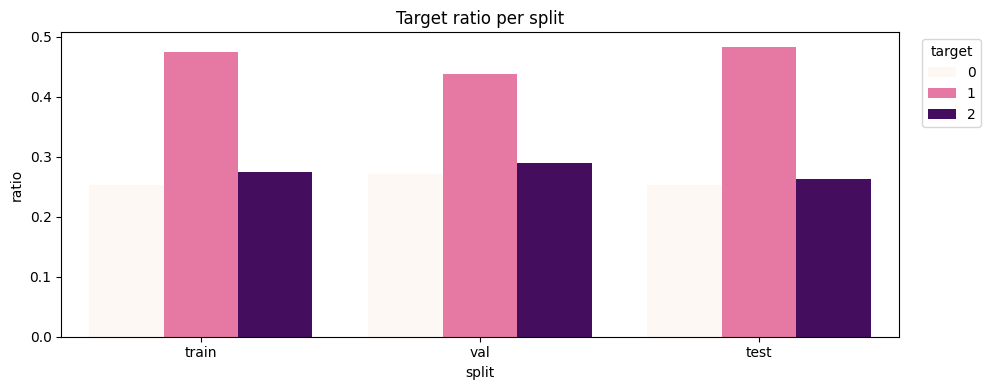

In [8]:
def class_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df['target'].value_counts().sort_index()
    ratios = (counts / len(df)).round(4)
    out = pd.DataFrame({
        'split': split_name,
        'target': counts.index,
        'count': counts.values,
        'ratio': ratios.values,
    })
    return out

per_split_report = pd.concat(
    [
        class_distribution(train_df, 'train'),
        class_distribution(val_df, 'val'),
        class_distribution(test_df, 'test'),
    ],
    ignore_index=True,
)
styler.style_me(per_split_report, title='Class distribution per split')

plt.figure(figsize=(10, 4))
sns.barplot(data=per_split_report, x='split', y='ratio', hue='target', palette='RdPu')
plt.title('Target ratio per split')
plt.xlabel('split')
plt.ylabel('ratio')
plt.legend(title='target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Split Timeline Visualization

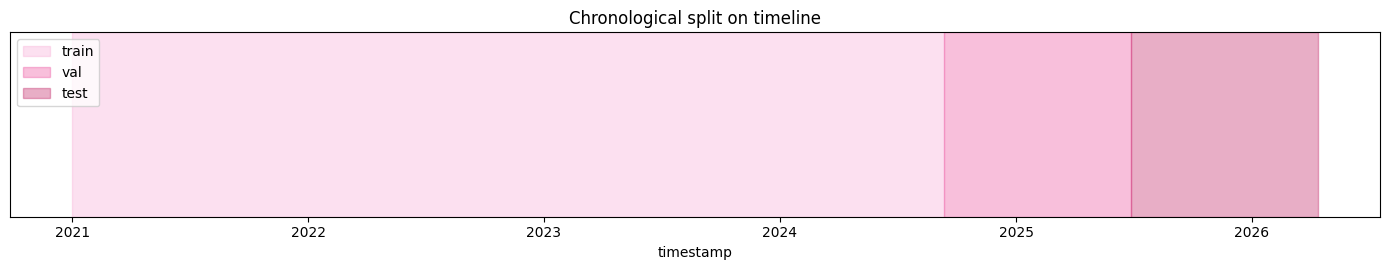

In [9]:
plt.figure(figsize=(14, 2.8))
plt.axvspan(train_df['timestamp'].min(), train_df['timestamp'].max(), alpha=0.35, color='#f9a8d4', label='train')
plt.axvspan(val_df['timestamp'].min(), val_df['timestamp'].max(), alpha=0.35, color='#ec4899', label='val')
plt.axvspan(test_df['timestamp'].min(), test_df['timestamp'].max(), alpha=0.35, color='#be185d', label='test')
plt.yticks([])
plt.xlabel('timestamp')
plt.title('Chronological split on timeline')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Data saving

In [10]:
TRAIN_OUT = LABELED_PATH + 'train_labeled.csv'
VAL_OUT = LABELED_PATH + 'val_labeled.csv'
TEST_OUT = LABELED_PATH + 'test_labeled.csv'
SPLIT_SUMMARY_OUT = LABELED_PATH + 'split_summary.csv'
CLASS_REPORT_OUT = LABELED_PATH + 'class_distribution_per_split.csv'

train_df.to_csv(TRAIN_OUT, index=False)
val_df.to_csv(VAL_OUT, index=False)
test_df.to_csv(TEST_OUT, index=False)

split_size_report.to_csv(SPLIT_SUMMARY_OUT, index=False)
per_split_report.to_csv(CLASS_REPORT_OUT, index=False)

styler.show_line(TRAIN_OUT, title='Saved train split')
styler.show_line(VAL_OUT, title='Saved val split')
styler.show_line(TEST_OUT, title='Saved test split')
styler.show_line(SPLIT_SUMMARY_OUT, title='Saved split summary')
styler.show_line(CLASS_REPORT_OUT, title='Saved class distribution report')


### Final thoughts:

